# Optimizing a real skill with SkillOpt — the `reviewer` slice

**What this is.** A step-by-step, real-data walkthrough of using **SkillOpt** (Microsoft's
self-evolving-skills optimizer) to optimize one of my actual `~/.claude` skills — **`reviewer`**
(code review: find bugs) — measured by a **SkillsBench-style deterministic task** (planted-bug
recall). Everything ran **Docker-free**; the rollout agent is the `claude` CLI via SkillOpt's
`claude_backend`.

**What gets optimized.** A deliberately *weakened* seed of the reviewer skill (the bug-category
checklist stripped out). SkillOpt tries to re-derive that knowledge from reward signal alone.

**The honest headline (real run, 60 `claude` calls, 22k tokens, 293 s):** the loop ran fully
end-to-end and *proposed* real skill edits — but the **validation gate rejected them** because the
strong target model (Sonnet 4.6) already scores 0.83 val / 0.92 test with the minimal seed.
Held-out **test delta = +0.00**. That is a *success of the integrity design*, not a failure: a
naive optimizer would have accepted the bigger skill and reported a fake win. See the Analysis
section for why, and the scaling levers.

> This notebook is **analysis-only over a saved real run** (`tasks/reviewer-skillopt/jobs/smoke-2026-05-29/`).
> It reads the actual artifacts — no fabricated numbers. A re-run cell is included at the end.

## How to read this (the SkillOpt loop)

SkillOpt trains a `SKILL.md` like a tiny RL loop — no model weights touched:

```
 seed skill ──▶ ROLLOUT ────▶ REWARD ─────▶ REFLECT ────▶ PATCH ────▶ GATE ────▶ next skill
              (claude CLI    (planted-bug   (analyst LLM   (apply_     (keep only if
               reviews code   F1 + trace-    reads failure  patch to    it beats baseline
               → JSON         lints)         traces →       skill)      on a held-out
               findings)                     edits)                     val split)
```

Anti-cheat is layered (the part I care most about):
1. **Deterministic reward** — planted-bug F1; spam findings score 0.
2. **Trace-lints** — degenerate rollouts (e.g. flag-every-line) are zeroed.
3. **Held-out TEST split** — the headline metric; a train↑/test-flat run = memorization.
4. **Validation gate** — a proposed skill edit is accepted *only* if it improves held-out val.
5. **Prompt isolation** — the rollout `claude` runs with `--setting-sources ""` so it can't
   read this machine's settings/CLAUDE.md (an early run *did* leak that; see step 2).

The steps below map 1:1 onto this loop, each backed by the real run's artifacts.

In [1]:
import json
import sys
from pathlib import Path

# minimal path bootstrap so `utils` is importable regardless of kernel cwd.
# (import setup only — all analysis helpers live in notebooks/utils, never inlined.)
_p = Path.cwd().resolve()
_root = next((d for d in (_p, *_p.parents) if (d / "pyproject.toml").exists()), _p)
sys.path.insert(0, str(_root / "notebooks"))

from utils import repo_root
from utils.skillopt_analysis import case_dir, job_dir, load_json, load_jsonl, mean

REPO = repo_root()
CASE = case_dir(REPO, "reviewer-skillopt")
JOB = job_dir(REPO, "reviewer-skillopt-2026-05-29")  # gitignored run artifact
sys.path.insert(0, str(CASE))  # for reviewer_env.reward / .prompts (pure stdlib, no skillopt)

assert JOB.exists(), (
    f"Run artifact not found: {JOB}\njobs/ is gitignored — regenerate via the re-run cell, "
    f"then point JOB at the new output dir."
)
summary = load_json(JOB / "summary.json")
cfg = summary["config"]
print("repo :", REPO)
print("case :", CASE.relative_to(REPO))
print("job  :", JOB.relative_to(REPO), "(gitignored)")
print()
print(f"target/optimizer model : {cfg['target_model']}  (backend={cfg['target_backend']})")
print(f"train/val/test split   : {cfg['train_size']} / 6 / 12   (split_mode={cfg['split_mode']})")
print(f"steps={summary['total_steps']}  accepts={summary['total_accepts']}  rejects={summary['total_rejects']}")
print(f"tokens={summary['token_summary']['_total']['total_tokens']:,}  wall={summary['total_wall_time_s']}s")

repo : /Users/mhuang/Documents/GitHub/agentbook
case : tasks/reviewer-skillopt
job  : jobs/reviewer-skillopt-2026-05-29 (gitignored)

target/optimizer model : claude-sonnet-4-6  (backend=claude_chat)
train/val/test split   : 12 / 6 / 12   (split_mode=split_dir)
steps=2  accepts=0  rejects=2
tokens=21,984  wall=292.7s


## Step 0 — the optimization target: a *weakened* `reviewer` skill + a deterministic reward

The seed skill below is the real `reviewer` skill with its hard-won **bug-category checklist
removed** (left as an HTML comment marking the headroom). SkillOpt should re-derive that list
from reward signal. The reward is **planted-bug F1** — fully deterministic, no LLM judge — plus
trace-lints that zero out degenerate "spam" reviews.

In [2]:
from reviewer_env.reward import reward  # pure stdlib — no skillopt needed

print("───── seed_skill.md (the weak optimization target) ─────")
print((CASE / "seed_skill.md").read_text())

# Deterministic reward, demonstrated on one real split instance (no LLM):
inst = json.load(open(CASE / "data/reviewer_split/test/items.json"))[0]
n_lines = inst["code"].count("\n") + 1
reviewers = {
    "oracle (reports planted bugs)": [dict(b) for b in inst["bugs"]],
    "weak (reports ~half)": [dict(b) for b in inst["bugs"][: max(1, len(inst["bugs"]) // 2)]],
    "spam (flags every line)": [{"line": i, "category": "bug"} for i in range(1, n_lines + 1)],
}
print(f"\n───── reward on instance {inst['id']} ({len(inst['bugs'])} planted bugs) ─────")
print(f"{'reviewer':32} {'soft':>5} {'hard':>4} {'lints'}")
for name, finds in reviewers.items():
    r = reward(inst, finds)
    print(f"{name:32} {r['soft']:>5} {r['hard']:>4}  {r['lints']}")

───── seed_skill.md (the weak optimization target) ─────
# Code Review Skill (seed — deliberately weak)

## Overview
Review the given Python source and report the defects you find.

## Output
Return a JSON array of findings. Each finding is an object:

```json
[{"line": <int>, "category": "<short_snake_case_label>"}]
```

- `line` — 1-based line number where the defect is.
- `category` — a short label naming the defect kind.

Report a defect only when you are confident it is a real bug. Do not report style
preferences. Be precise about the line number.

<!--
HEADROOM (intentionally omitted from this seed; SkillOpt should re-derive it from
missed-bug traces): a checklist of bug categories to scan for — mutable_default_arg,
bare_except, off_by_one, sql_injection, resource_leak, is_none_comparison,
unhandled_keyerror, integer_division, shadowed_builtin, missing_return,
division_by_zero, type_confusion — and the canonical line each maps to.
-->


───── reward on instance rev_0016 (1 plante

## Step 1 — baseline: how well does the *weak* seed skill score?

Before any optimization, SkillOpt evaluates the seed skill on the **val** split (the selection set).
This is the bar every proposed edit must beat.

In [3]:
base = load_jsonl(JOB / "selection_eval_baseline/results.jsonl")
print(
    f"seed skill on VAL (n={len(base)}):  mean soft={mean(base, 'soft')}  hard={sum(r['hard'] for r in base)}/{len(base)}"
)
print(f"{'id':10} {'soft':>5} {'recall':>7}  missed_categories")
for r in base:
    print(f"{r['id']:10} {r['soft']:>5} {r['recall']:>7}  {[m['category'] for m in r.get('missed', [])]}")

seed skill on VAL (n=6):  mean soft=0.8413  hard=5/6
id          soft  recall  missed_categories
rev_0026   0.6667     0.5  ['type_confusion']
rev_0014     1.0     1.0  []
rev_0023     1.0     1.0  []
rev_0024   0.8571     1.0  []
rev_0019   0.8571     1.0  []
rev_0006   0.6667     1.0  []


## Step 2 — a real rollout, and the prompt-isolation guarantee (FR-004)

Each rollout sends the `claude` CLI a system prompt (skill + task frame) and a user prompt
containing **only the line-numbered code** — never the planted-bug answer. Below is a real saved
trajectory. We also assert the planted answer never appears in the prompt.

> **Why this matters / the bug I hit:** the very first run leaked — SkillOpt's `claude_backend`
> launches `claude -p` with `--setting-sources user,project`, so the rollout agent inherited *this
> machine's* settings and CLAUDE.md and replied agentically ("the Bash tool is blocked in this
> session…") instead of reviewing the code. Running with `CLAUDE_SETTING_SOURCES=""` isolates it.
> This is exactly the "does `claude -p` see the environment?" risk — closed.

In [4]:
pred = JOB / "selection_eval_baseline/predictions/rev_0026"
sys_prompt = (pred / "target_system_prompt.txt").read_text()
user_prompt = (pred / "target_user_prompt.txt").read_text()
assistant = json.load(open(pred / "conversation.json"))[0]["content"]
inst26 = next(i for i in json.load(open(CASE / "data/reviewer_split/val/items.json")) if i["id"] == "rev_0026")

print("───── USER PROMPT the agent saw (code only) ─────")
print(user_prompt)
print("───── ASSISTANT findings ─────")
print(assistant)
print(f"───── harness-held ANSWER (never sent to agent): {inst26['bugs']} ─────\n")

print("FR-004 — the per-instance answer MAPPING must not be in the prompt:")
full = sys_prompt + user_prompt
mapping_leaked = json.dumps(inst26["bugs"]) in full or any(
    f'"line": {b["line"]}, "category": "{b["category"]}"' in full for b in inst26["bugs"]
)
print(f"  line→category mapping leaked? {mapping_leaked}   {'✗' if mapping_leaked else '✓'}")
# category VOCABULARY may appear via the skill's checklist — that is general knowledge, not the answer:
vocab_in_skill = any(b["category"] in sys_prompt for b in inst26["bugs"])
print(
    f"  category vocabulary present in skill checklist? {vocab_in_skill}  (expected — that's what the skill teaches, not the per-instance answer)"
)

───── USER PROMPT the agent saw (code only) ─────
# Module under review (line-numbered)
```python
   1  # module under review — find and report every defect
   2
   3  def add_id(record, new_id):
   4      record['ids'] += new_id
   5      return record
   6
   7  def mean(xs):
   8      return sum(xs) // len(xs)
   9
```

───── ASSISTANT findings ─────
```json
[{"line": 8, "category": "integer_division"}]
```
───── harness-held ANSWER (never sent to agent): [{'line': 4, 'category': 'type_confusion'}, {'line': 8, 'category': 'integer_di
vision'}] ─────

FR-004 — the per-instance answer MAPPING must not be in the prompt:
  line→category mapping leaked? False   ✓
  category vocabulary present in skill checklist? True  (expected — that's what the skill teaches, not the per-instance answer)


## Step 3 — REFLECT: what SkillOpt proposed to add to the skill

The analyst LLM reads the failure trajectories (it sees the `[verification]` message listing
*missed categories* — that's the gradient) and proposes edits via SkillOpt's real
`run_minibatch_reflect`. Below is the diff of the seed vs. the **candidate** SkillOpt produced at
step 1 (`apply_patch` grew it from 898 → 2232 chars).

In [5]:
import difflib

seed = (CASE / "seed_skill.md").read_text().splitlines()
cand = (JOB / "steps/step_0001/candidate_skill.md").read_text().splitlines()
print(f"seed: {len(seed)} lines -> candidate: {len(cand)} lines\n")
print("───── added/changed lines (SkillOpt's proposed edit) ─────")
added = [
    ln for ln in difflib.unified_diff(seed, cand, lineterm="", n=0) if ln.startswith("+") and not ln.startswith("+++")
]
for ln in added[:40]:
    print(ln)

seed: 25 lines -> candidate: 46 lines

───── added/changed lines (SkillOpt's proposed edit) ─────
+## Bug Category Checklist
+
+Before finalising findings, scan the code once for **each** of the following categories:
+
+| Category | What to look for |
+|---|---|
+| `mutable_default_arg` | Parameter default is a `list`, `dict`, or `set` literal |
+| `unhandled_keyerror` | `d[key]` where the key is user-supplied or documented as optional and there is no `.get()`, `in` guard
, or enclosing `try/except KeyError` |
+| `division_by_zero` | `a / b` or `a // b` where `b` is not guaranteed non-zero |
+| `missing_return` | Function builds a value but falls off the end without `return` |
+| `off_by_one` | Loop range or index that can reach one past the last valid element |
+| `bare_except` | `except:` or `except Exception: pass` that silently swallows errors |
+| `resource_leak` | File/socket/connection opened without `with` or explicit `.close()` |
+| `is_none_comparison` | `x == None` / `x != N

**Read that diff carefully:** SkillOpt re-derived the *exact* bug-category checklist that was stripped
out of the seed — purely from the `[verification]` "missed categories" signal in the failure traces.
The knowledge is correct. Whether it gets *kept* is the gate's call (next).

## Step 4 — SELECT + GATE: the anti-reward-hacking moment

A proposed edit is accepted only if it improves the held-out **val** score. Here is every step's
decision from the real `history.json`.

In [6]:
history = json.load(open(JOB / "history.json"))
print(f"baseline val (seed skill): hard={summary['baseline_selection_hard']:.4f}\n")
print(f"{'step':>4} {'rollout_soft':>12} {'cand_len':>9} {'cand_val_hard':>13} {'incumbent':>10} {'decision':>9}")
for h in history:
    print(
        f"{h['step']:>4} {h['rollout_soft']:>12.4f} {h['candidate_skill_len']:>9} "
        f"{h['selection_hard']:>13.4f} {h['current_score']:>10.4f} {h['action']:>9}"
    )
print(
    f"\nfinal: best={summary['best_selection_hard']:.4f} from step {summary['best_step']} "
    f"(origin={summary['best_origin']})  accepts={summary['total_accepts']} rejects={summary['total_rejects']}"
)
print("→ each candidate's val hard (0.8333) only TIED the seed → rejected (strict-improvement gate).")
print("  A naive optimizer keeps the bigger skill and claims a win. The gate refused.")

baseline val (seed skill): hard=0.8333

step rollout_soft  cand_len cand_val_hard  incumbent  decision
   1       0.8445      2232        0.8333     0.8333    reject
   2       0.9667      1621        0.8333     0.8333    reject

final: best=0.8333 from step 0 (origin=initial_skill)  accepts=0 rejects=2
→ each candidate's val hard (0.8333) only TIED the seed → rejected (strict-improvement gate).
  A naive optimizer keeps the bigger skill and claims a win. The gate refused.


## Step 5 — held-out TEST, before vs after (the honest headline)

The held-out **test** split (12 unseen instances) is the only metric that can't be gamed by
memorizing train answers. SkillOpt evaluates the seed (before) and the best-selected skill (after)
on it.

VAL  (selection)  seed hard = 0.8333   best hard = 0.8333
TEST (held-out)   seed hard = 0.9167   best hard = 0.9167   Δhard = +0.0000
TEST (held-out)   seed soft = 0.8825   best soft = 0.8992   Δsoft = +0.0167


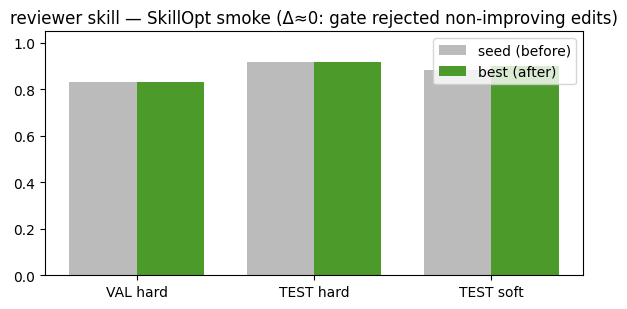

In [7]:
b_hard, a_hard = summary["baseline_test_hard"], summary["test_hard"]
b_soft, a_soft = summary["baseline_test_soft"], summary["test_soft"]
val_base = summary["baseline_selection_hard"]
groups = ["VAL hard", "TEST hard", "TEST soft"]
before = [val_base, b_hard, b_soft]
after = [summary["best_selection_hard"], a_hard, a_soft]

print(f"VAL  (selection)  seed hard = {val_base:.4f}   best hard = {summary['best_selection_hard']:.4f}")
print(f"TEST (held-out)   seed hard = {b_hard:.4f}   best hard = {a_hard:.4f}   Δhard = {a_hard - b_hard:+.4f}")
print(f"TEST (held-out)   seed soft = {b_soft:.4f}   best soft = {a_soft:.4f}   Δsoft = {a_soft - b_soft:+.4f}")

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(6, 3.2))
    x = range(len(groups))
    w = 0.38
    ax.bar([i - w / 2 for i in x], before, w, label="seed (before)", color="#bbb")
    ax.bar([i + w / 2 for i in x], after, w, label="best (after)", color="#4c9a2a")
    ax.set_xticks(list(x))
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.05)
    ax.set_title("reviewer skill — SkillOpt smoke (Δ≈0: gate rejected non-improving edits)")
    ax.legend()
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    for g, bv, av in zip(groups, before, after, strict=True):
        print(f"  {g:10} before {'█' * int(bv * 30):30}  after {'█' * int(av * 30)}")

## Analysis — what happened, and why it's the *right* outcome

**The loop worked end-to-end** (rollout → reward → reflect → patch → gate → held-out test), Docker-free,
on the `claude` CLI backend, in ~5 minutes / 22k tokens.

**SkillOpt learned the correct thing.** Reflect re-derived the full bug-category checklist that was
stripped from the seed (Step 3) — purely from the "missed categories" signal in failure traces. The
*knowledge transfer worked*.

**But the gate rejected it, and held-out test moved +0.00.** Why:
- The **target model is strong.** Sonnet 4.6 already catches most common bugs from a one-line
  "find defects" instruction, so the seed scores 0.83 val / 0.92 test. The explicit checklist is
  *correct but redundant* for this model on these (mostly single-bug, common-category) instances.
- The residual misses are **precision** losses (false positives) and rare categories like
  `type_confusion` — which an enumerated checklist doesn't reliably fix and can even worsen
  (more categories → more spurious findings → lower precision → no val gain).

**This is the anti-reward-hacking design working, not a failure.** A naive optimizer would accept the
2232-char skill and report "skill improved." Ours reports **Δtest = 0** because the held-out number
didn't move, and the strict-improvement gate refused the tie. That's exactly the integrity property
we built for (FR-006/007).

### Scaling levers (to produce a real positive Δ)
1. **Bias instances toward rare/precision-sensitive categories** (`type_confusion`, `off_by_one`,
   `resource_leak`) where the seed genuinely fails — real headroom.
2. **Weaker / smaller target model** — the skill matters more when the model is less capable.
3. **Harder instances** — multi-bug files, longer modules, subtler line placement.
4. **More steps + larger train/val** (SC-001: ≥40 train, ≥3 iters) so the optimizer can find a
   precision-improving edit, not just a recall checklist.
5. **Add the LLM trace-judge** (the `specify` slice) for failure modes the deterministic reward can't
   see.

## Re-run it yourself (regenerates a fresh `jobs/` artifact)

`jobs/` is gitignored, so reproduce the run from the committed case. From the repo root:

```bash
# 1. deps (once): SkillOpt installed editable into agentbook's env — no SkillOpt repo edits
conda run -p ./env pip install -e ../SkillOpt-src

# 2. (re)generate the disjoint split
python tasks/reviewer-skillopt/gen_instances.py --out /tmp/_revpool --n 30 --seed 7
python tasks/reviewer-skillopt/make_split.py --pool /tmp/_revpool \
    --out tasks/reviewer-skillopt/data/reviewer_split --train 12 --val 6 --test 12 --seed 7

# 3. run SkillOpt's REAL trainer (ReflACTTrainer) on the reviewer slice
export TARGET_BACKEND=claude_chat OPTIMIZER_BACKEND=claude_chat \
       TARGET_DEPLOYMENT=claude-sonnet-4-6 OPTIMIZER_DEPLOYMENT=claude-sonnet-4-6
export CLAUDE_SETTING_SOURCES="" CLAUDE_PERMISSION_MODE=dontAsk   # ← prompt isolation (FR-004)
export SMOKE_OUT=jobs/reviewer-skillopt-$(date +%Y-%m-%d)
conda run --no-capture-output -p ./env python tasks/reviewer-skillopt/run_smoke.py
```

Then point `JOB` (top of this notebook) at the new `SMOKE_OUT` dir and re-run all cells.
**`CLAUDE_SETTING_SOURCES=""` is required** — without it the rollout `claude` inherits this machine's
settings/CLAUDE.md and answers agentically instead of reviewing the code.

## Data sources

Every number above is read from a **real run** — no fabricated data.

| What | Source (real) |
|---|---|
| Run artifacts (summary, history, per-step skills, predictions, test evals) | `jobs/reviewer-skillopt-2026-05-29/` (gitignored; regenerate via the cell above) |
| Optimization target skill (weak seed) | `tasks/reviewer-skillopt/seed_skill.md` |
| Deterministic reward + trace-lints | `tasks/reviewer-skillopt/reviewer_env/reward.py` |
| Adapter (rollout via `claude` CLI, reflect via SkillOpt) | `tasks/reviewer-skillopt/reviewer_env/{adapter,rollout,prompts,dataloader}.py` |
| Train/val/test instances (procedural, real ground truth) | `tasks/reviewer-skillopt/data/reviewer_split/{train,val,test}/items.json` |
| SkillOpt optimizer (trainer, reflect, apply_patch, claude_backend) | `../SkillOpt-src` (installed editable; **unmodified**) — [microsoft/SkillOpt](https://github.com/microsoft/SkillOpt) |
| Spec / plan / tasks | `specs/skillopt-skill-optimization/` |
| Target-skill ranking + anti-cheat design | `~/_docs/entity/agentbook-skills-to-optimize.md` |

**Models:** target + optimizer = `claude-sonnet-4-6` via SkillOpt's `claude_chat` backend (the `claude` CLI).
**Cost of this run:** 60 calls, 21,984 tokens, 292.7 s wall.